# Data Preparation on Respiratory Virus Dashboard Dataset

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import PowerTransformer
from pandas.api.types import is_numeric_dtype

from src.compare import compare_transformations
from src.enums import rv_keys, prefixes
from src.serialize import dump_to_file

rv = pd.read_csv('03-26-respiratory-virus-dashboard-2023-2026.csv')

## Clean up respiratory virus data

Remove mostly null and non-representative columns from respiratory virus data.

In [9]:
rv_cleaned = rv.copy()
rv_cleaned = rv.drop([
    rv_keys['FLU_A_TESTS'], # Dropped because 3/4 of the data is missing.
    rv_keys['FLU_B_TESTS'], # Dropped because 3/4 of the data is missing.
    rv_keys['COV_ADM'], # Although only 1/5 of this data is missing, the corresponding columns in other virus categories have much higher rates of null values, so we are dropping them together to maintain consistency.
    rv_keys['FLU_ADM'], # Dropped because half of the data is missing.
    rv_keys['RSV_ADM'], # Dropped because half of the data is missing.
    rv_keys['COV_ADM_RATE'], # Although only 1/5 of this data is missing, the corresponding columns in other virus categories have much higher rates of null values, so we are dropping them together to maintain consistency.
    rv_keys['FLU_ADM_RATE'], # Dropped because half of the data is missing.
    rv_keys['RSV_ADM_RATE'], # Dropped because half of the data is missing.
    rv_keys['COV_ADM_LEVEL'], # Although only 1/5 of this data is missing, the corresponding columns in other virus categories have much higher rates of null values, so we are dropping them together to maintain consistency.
    rv_keys['FLU_ADM_LEVEL'], # Dropped because half of the data is missing.
    rv_keys['RSV_ADM_LEVEL'], # Dropped because half of the data is missing.
    rv_keys['POP'], # Dropped because 1/5 of this data is missing and there is very little variance.
], axis=1)

rv_preview = rv_cleaned.copy()
rv_columns_with_null = []

for key in rv_preview.columns.tolist():
    null_count = rv_preview[key].isna().sum()
    if null_count > 0:
        rv_columns_with_null.append(key)

print(f"Columns with null values: {len(rv_columns_with_null)}")
rv_preview.head(3)

Columns with null values: 0


,SEASON,WEEKENDING,MMWR_WEEK,MMWR_YEAR,COV_POSITIVES,COV_TOTAL_TESTS,COV_TP,COV_TP_LEVEL,FLU_POSITIVES,FLU_TOTAL_TESTS,...,RSV_TOTAL_TESTS,RSV_TP,RSV_TP_LEVEL,TOTAL_DEATHS,COV_DEATHS,FLU_DEATHS,RSV_DEATHS,COV_DEATHS_PER,FLU_DEATHS_PER,RSV_DEATHS_PER
0,2023/2024,07/08/2023,27,2023,1799,40924,4.395953,Low,69,1545,...,1550,0.516129,Very Low,1068.0,22,1,0,2.059925,0.093633,0.000000
1,2023/2024,07/15/2023,28,2023,2050,41354,4.957199,Low,92,1670,...,1641,0.670323,Very Low,1013.0,16,0,0,1.579467,0.000000,0.000000
2,2023/2024,07/22/2023,29,2023,2226,41390,5.378111,Low,46,1531,...,1518,0.922266,Very Low,1042.0,17,0,1,1.631478,0.000000,0.095969


## Stabilize respiratory virus data

Apply transformation to skewed columns to stabilize variance and make the data more normally distributed.

### Compare skewness across different transformations

In [10]:
compare_transformations(rv_cleaned)

,Original,Square root,Log transformation,Cube root,Yeo-Johnson Transform
SEASON,N/A,N/A,N/A,N/A,N/A
WEEKENDING,N/A,N/A,N/A,N/A,N/A
MMWR_WEEK,-0.2,-0.69,-1.25,-0.91,-0.32
MMWR_YEAR,-0.05,-0.05,-0.05,-0.05,-0.03
COV_POSITIVES,0.84,0.31,-0.43,0.09,-0.07
COV_TOTAL_TESTS,0.03,-0.12,-0.27,-0.17,-0.1
COV_TP,0.65,0.19,-0.06,0.02,-0.02
COV_TP_LEVEL,N/A,N/A,N/A,N/A,N/A
FLU_POSITIVES,2.42,1.2,0.2,0.83,0.05
FLU_TOTAL_TESTS,0.58,-0.05,-0.97,-0.31,-0.06


In [11]:
transformations = {
    rv_keys['COV_POSITIVES']: 'sqrt',
    rv_keys['COV_TP']: 'sqrt',
    rv_keys['FLU_TOTAL_TESTS']: 'sqrt',
    rv_keys['RSV_TOTAL_TESTS']: 'sqrt',
    rv_keys['COV_DEATHS']: 'sqrt',
    rv_keys['COV_DEATHS_PER']: 'sqrt',

    rv_keys['FLU_POSITIVES']: 'log1p',
    rv_keys['FLU_TP']: 'log1p',
    rv_keys['RSV_POSITIVES']: 'log1p',
    rv_keys['RSV_TP']: 'log1p',

    rv_keys['TOTAL_DEATHS']: 'yeo-johnson',
    rv_keys['FLU_DEATHS']: 'yeo-johnson',
    rv_keys['RSV_DEATHS']: 'yeo-johnson',
    rv_keys['FLU_DEATHS_PER']: 'yeo-johnson',
    rv_keys['RSV_DEATHS_PER']: 'yeo-johnson',
}

rv_transformed = rv_cleaned.copy()

for feature, transformation in transformations.items():
    if transformation == 'sqrt':
        rv_transformed[feature] = np.sqrt(rv_cleaned[feature])
    elif transformation == 'log1p':
        rv_transformed[feature] = np.log1p(rv_cleaned[feature])
    elif transformation == 'yeo-johnson':
        power_transformer = PowerTransformer(method='yeo-johnson')
        rv_transformed[feature] = power_transformer.fit_transform(rv_cleaned[[feature]]).ravel()
        dump_to_file(power_transformer, prefixes['03_30_data_preparation_respiratory_virus_dashboard_']+feature)

### Skewness comparison

In [12]:
skew_cleaned = {}
skew_transformed = {}
transformations_comparison = {}

for column in rv_transformed.columns:
    if column in transformations:
        transformations_comparison[column] = transformations[column]
    else:
        transformations_comparison[column] = 'None'

for column in rv_transformed.columns:
    if not is_numeric_dtype(rv_cleaned[column]):
        skew_cleaned[column] = 'N/A'
        skew_transformed[column] = 'N/A'
        continue

    skew_cleaned[column] = round(rv_cleaned[column].skew(), 2)
    skew_transformed[column] = round(rv_transformed[column].skew(), 2)

pd.DataFrame({
    'Transformation': transformations_comparison,
    'Skewness (Original)': skew_cleaned,
    'Skewness (Transformed)': skew_transformed
})

,Transformation,Skewness (Original),Skewness (Transformed)
SEASON,None,N/A,N/A
WEEKENDING,None,N/A,N/A
MMWR_WEEK,None,-0.2,-0.2
MMWR_YEAR,None,-0.05,-0.05
COV_POSITIVES,sqrt,0.84,0.31
COV_TOTAL_TESTS,None,0.03,0.03
COV_TP,sqrt,0.65,0.19
COV_TP_LEVEL,None,N/A,N/A
FLU_POSITIVES,log1p,2.42,0.2
FLU_TOTAL_TESTS,sqrt,0.58,-0.05


### Distribution comparison

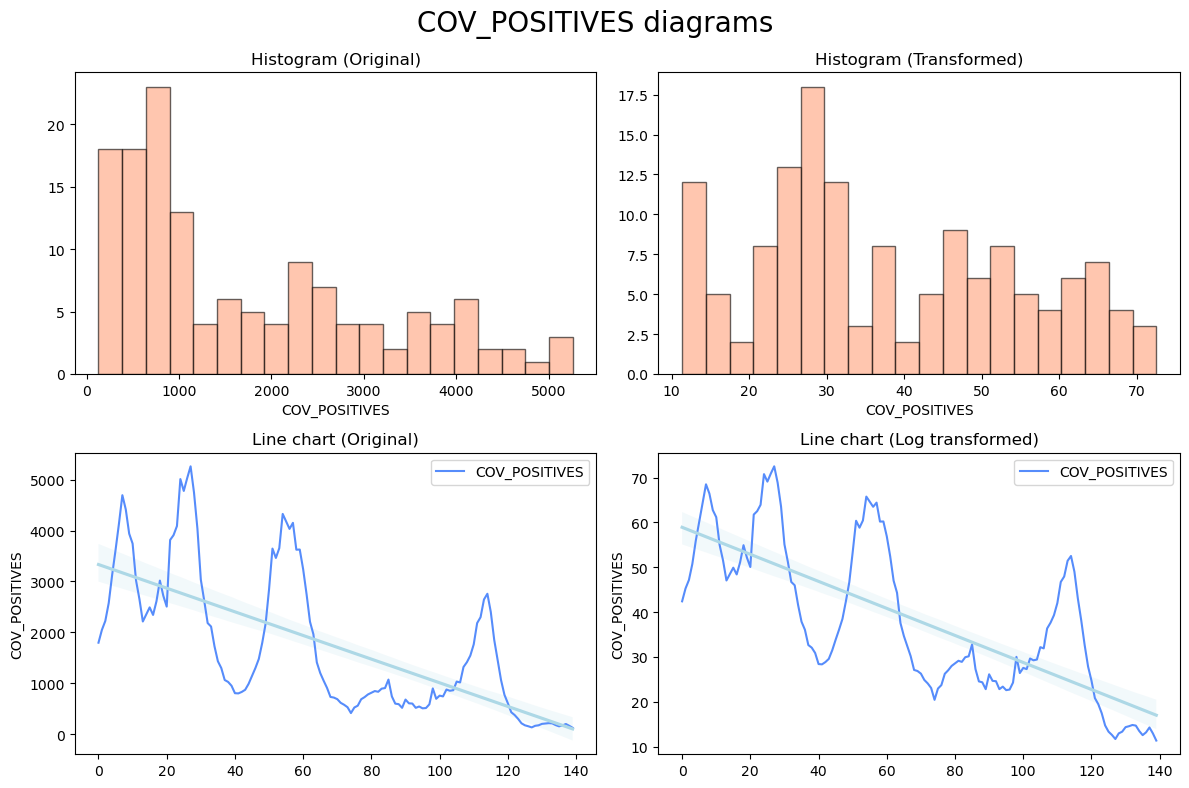

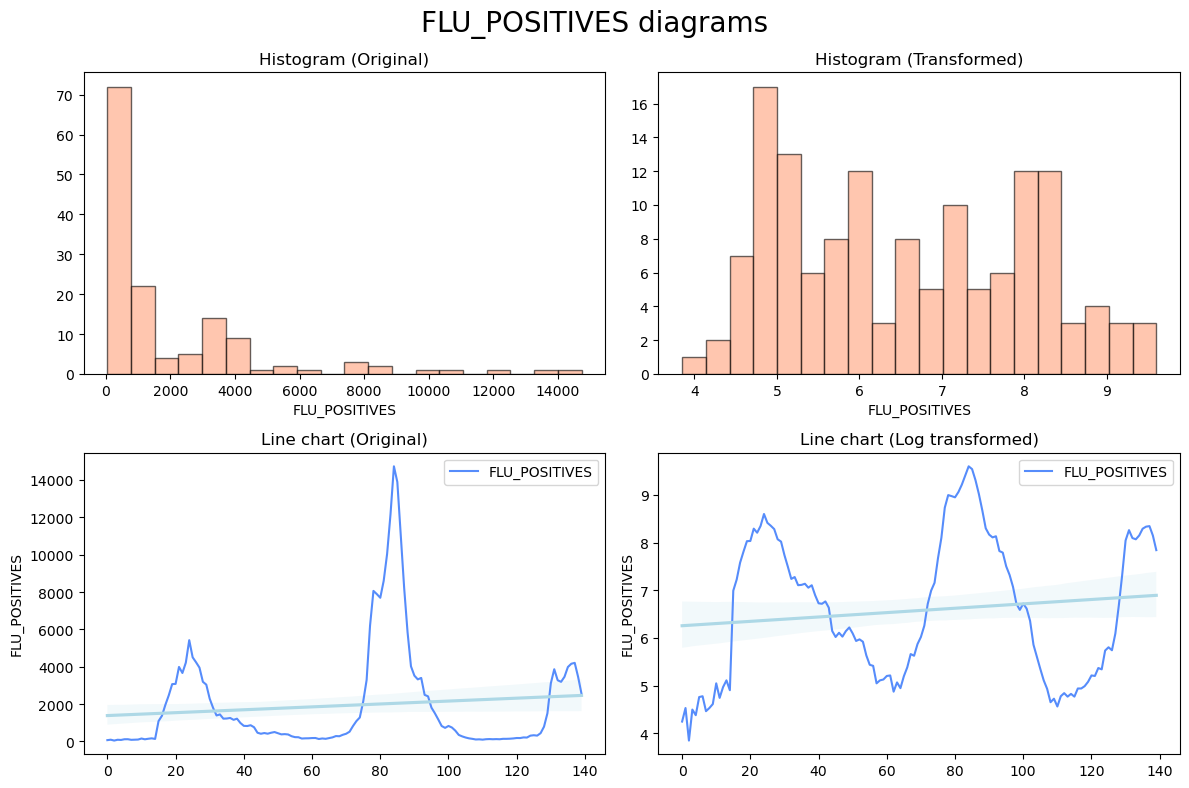

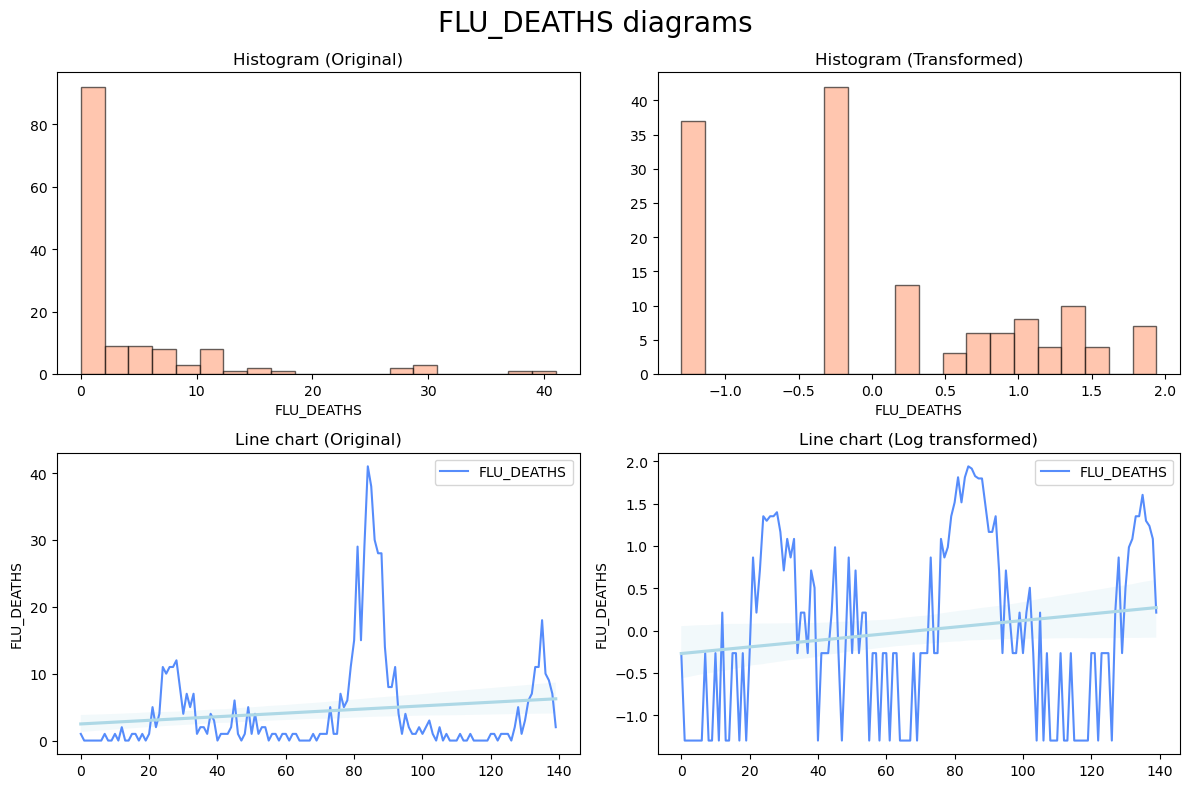

In [13]:
features_comparison = [
    rv_keys['COV_POSITIVES'], # square root transformation.
    rv_keys['FLU_POSITIVES'], # log transformation.
    rv_keys['FLU_DEATHS'] # Yeo-Johnson transformation.
]

for feature_comparison in features_comparison:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    plt.suptitle(feature_comparison + ' diagrams', fontsize=20)
    axes[0, 0].hist(rv_cleaned[feature_comparison], alpha = 0.6, bins=20, color='lightsalmon', edgecolor='black')
    axes[0, 0].set_title('Histogram (Original)')
    axes[0, 0].set_xlabel(feature_comparison)

    axes[0, 1].hist(rv_transformed[feature_comparison], alpha = 0.6, bins=20, color='lightsalmon', edgecolor='black')
    axes[0, 1].set_title('Histogram (Transformed)')
    axes[0, 1].set_xlabel(feature_comparison)

    rv_cleaned.plot(y=[feature_comparison], ax=axes[1, 0], title='Line chart (Original)', kind='line')
    sns.regplot(data=rv_cleaned, x=rv_cleaned.index, y=feature_comparison, ax=axes[1,0], scatter=False, color='lightblue')

    rv_transformed.plot(y=[feature_comparison], ax=axes[1,1], title='Line chart (Log transformed)', kind='line')
    sns.regplot(data=rv_transformed, x=rv_transformed.index, y=feature_comparison, ax=axes[1,1], scatter=False, color='lightblue')

    plt.tight_layout()
    plt.show()

## Checkpoint

In [14]:
rv_transformed = rv_transformed.sort_values(by=[rv_keys['MMWR_YEAR'], rv_keys['MMWR_WEEK']])
rv_transformed.to_csv('04-01-respiratory-virus-dashboard-2023-2026.csv', index=False)